/home/ebertp/work/projects/chrom-y-extended
/home/ebertp/work/cloud/sciebo/share/outgoing/projects/project-chrom-y-extended/plots/region-overlap-stats
=== source path
codebase/plotting/notebooks/region-overlap-stats/issue-by-group.ipynb
===
AMPL ERRBASE 142
AMPL ERRSTRUCT 40
AMPL NGAP 61
AMPL UNASSIGNED 105
CEN-DYZ3 ERRBASE 22
CEN-DYZ3 ERRSTRUCT 14
CEN-DYZ3 NGAP 18
DYZ19 ERRBASE 14
DYZ19 NGAP 1
DYZ19 UNASSIGNED 1
HET ERRBASE 120
HET ERRSTRUCT 45
HET NGAP 41
HET UNASSIGNED 129
OTH ERRBASE 99
OTH UNASSIGNED 4
PAR ERRBASE 142
PAR ERRSTRUCT 54
PAR NGAP 22
PAR UNASSIGNED 129
XDR ERRBASE 142
XDR ERRSTRUCT 1
XDR NGAP 3
XDR UNASSIGNED 5
XTR ERRBASE 142
XTR ERRSTRUCT 1
XTR NGAP 1
XTR UNASSIGNED 20
periCEN ERRBASE 142
periCEN ERRSTRUCT 8
periCEN UNASSIGNED 88


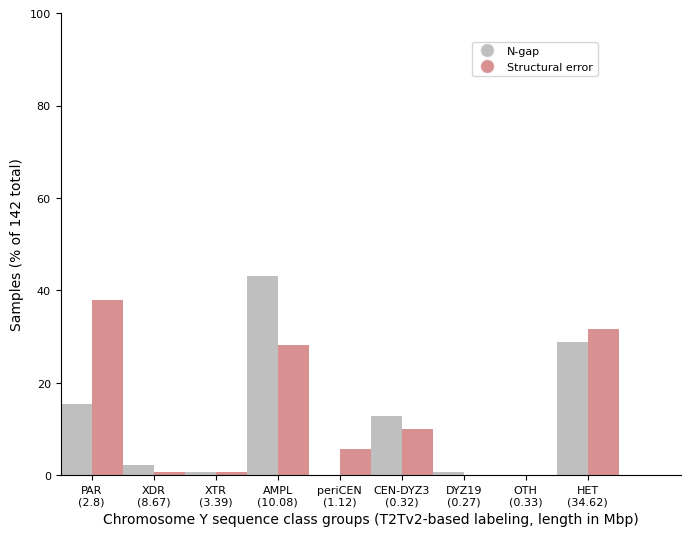

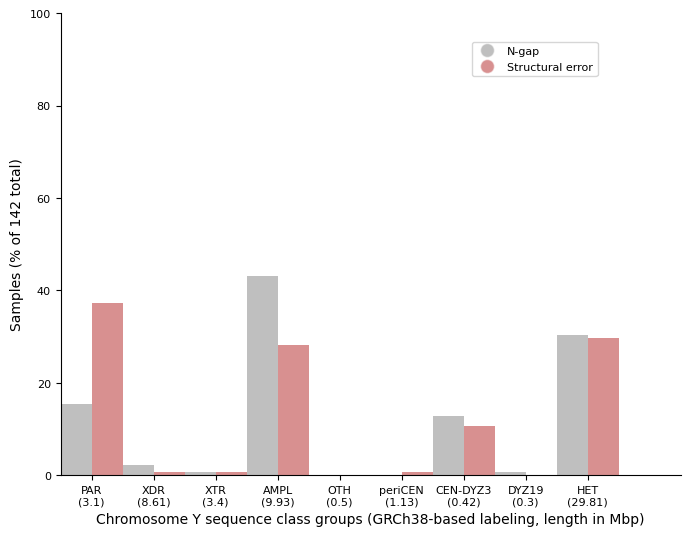

In [4]:
import pathlib as pl

cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
TABLE_ROOT = CONFIG["table_root"].joinpath(NB_PATH.stem)
NB_CACHE_FOLDER = CONFIG["nb_cache_folder"]
DATA_ROOT = CONFIG["project_data"]

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

print(DATA_ROOT)
print(PLOT_ROOT)

# actual NB code

import collections as col
import dataclasses as dcl
import pandas as pd
import re
import itertools as itt
import numpy.random as rng
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mplcol
import matplotlib.lines as mpllin
import math as ma



PAPER_CONTENT = True

if PAPER_CONTENT:
    print("=== source path")
    print(NB_REL_PATH)
    print("===")

ref_base_path = pl.Path("/home/ebertp/work/code/cubi/project-chrom-y-extended/annotation/norm")

ref_files = {
    "t2tv2": "HG002-Y_T2Tv2_regions_repeat-details.bed",
    "hg38": "GRCh38-Y_regions_repeat-details.bed"
}
ref_hg = {
    "t2tv2": "J1",
    "hg38": "R1"
}

ref_label = {
    "t2tv2": "T2Tv2",
    "hg38": "GRCh38"
}

label_mappings = DATA_ROOT.joinpath("/home/ebertp/work/projects/chrom-y-extended/wf-data/region-labels/umbrellas")

summary_files = list(
    DATA_ROOT.joinpath("wf-data/region-labels/error_assign").glob("*.tsv")
)

@dcl.dataclass
class IssueColors:
    NGAP = mplcol.to_rgba("grey", alpha=0.5)
    UNASSIGNED = mplcol.to_rgba("orange", alpha=0.5)
    ERRSTRUCT = mplcol.to_rgba("firebrick", alpha=0.5)
    ERRBASE = mplcol.to_rgba("skyblue", alpha=0.5)
    
    
    def get_color_labels(self):
        labels = [
            "N-gap",
            "Unassigned",
            "Structural error",
            "Base error",
            
        ]
        return labels

    def get_issue_labels(self):
        labels = [
            "NGAP",
            "UNASSIGNED",
            "ERRSTRUCT",
            "ERRBASE",
        ]
        return labels

COLORMAP = IssueColors()

legend_elements = []
    
for other, legend_label in zip(COLORMAP.get_issue_labels(), COLORMAP.get_color_labels()):
    # skipping - see below
    if other == "UNASSIGNED":
        continue
    if other == "ERRBASE":
        continue
    color = getattr(COLORMAP, other)
    elem = mpllin.Line2D(
        [], [], color="white",
        markerfacecolor=color, markersize=10,
        marker="o", label=legend_label
    )
    legend_elements.append(elem)



def load_label_order(ref):
    
    ref_regions_file = ref_base_path.joinpath(ref_files[ref])
    ref_regions = pd.read_csv(ref_regions_file, sep="\t", header=0)
    
    label_map_file = list(label_mappings.joinpath(ref).glob(f"{ref}*.json"))[0]
    label_map = json.load(open(label_map_file))

    ref_regions["group"] = ref_regions["name"].apply(lambda n: label_map.get(n, {"group": "umbrella"})["group"])
    ref_regions["length"] = ref_regions["end"] - ref_regions["start"]
    group_sizes = ref_regions.groupby("group")["length"].sum().to_dict()
    group_sizes["total"] = sum(v for k,v in group_sizes.items() if k != "umbrella")
    
    order = []
    seen = set()
    pos = 0
    for k in sorted(label_map.keys()):
        label_info = label_map[k]
        if label_info["group"] in seen:
            continue
        seen.add(label_info["group"])
        pos += 1
        order.append((pos, label_info["group"]))
    assert pos == len(order)
    return order, group_sizes

discard_telomere = False
assigned_issues = ["NGAP", "UNASSIGNED"]
overlap_issues = ["ERRSTRUCT", "ERRBASE"]

rel_abd = True
summary_by_sample = []

for summ_file in summary_files:
    ref = summ_file.name.split(".")[0]
    assert ref in ref_files
    label_order, group_sizes = load_label_order(ref)
    df = pd.read_csv(summ_file, sep="\t", header=0)
    num_samples = df["sample"].nunique()
    if discard_telomere:
        df = df.loc[df["assigned"] != "TELO", :].copy()

    x_labels = []
    x_regions = []
    bar_heights = []
        
    for pos, label in label_order:
        group_label_size = group_sizes[label]
        size_in_mbp = round(group_label_size/int(1e6), 2)
        x_regions.append(f"{label}\n({size_in_mbp})")
        select_label = df["label_group"] == label
        for assigned in assigned_issues:
            select_issue = df["name"] == assigned
            select_for = select_label & select_issue
            samples_hit = df.loc[select_for, "sample"].unique()
            # decision by PH: do not show the 'unassigned'
            # group because it is not meaningful enough ad hoc
            summary_by_sample.extend(
                [(ref, smp, label, assigned, 1) for smp in samples_hit]
            )
            if assigned == "UNASSIGNED":
                continue
            x_labels.append((label, assigned))
            if rel_abd:
                y_val = round(len(samples_hit) / num_samples * 100, 1)
            else:
                y_val = len(samples_hit)
            bar_heights.append(y_val)

        for overlapping in overlap_issues:
            select_issue = df[f"{overlapping}_n"] > 0
            select_for = select_label & select_issue
            samples_hit = df.loc[select_for, "sample"].unique()
            summary_by_sample.extend(
                [(ref, smp, label, overlapping, 1) for smp in samples_hit]
            )
            # decision 2026-03-10
            # drop ERRBASE
            if overlapping == "ERRBASE":
                continue
            x_labels.append((label, overlapping))
            if rel_abd:
                y_val = round(len(samples_hit) / num_samples * 100, 1)
            else:
                y_val = len(samples_hit)
            bar_heights.append(y_val)
        
    fig, ax = plt.subplots(figsize=(8,6))
    colors = [getattr(COLORMAP, t[1]) for t in x_labels]
    x_pos = np.arange(0.25/2, len(x_labels)+1, step=0.25)[:len(bar_heights)]
    last_x_pos = x_pos.max()
    #tick_labels = ["\n".join(label) for label in x_labels]
    ax.bar(
        x_pos[:len(bar_heights)],
        bar_heights,
        color=colors,
        width=0.25, linewidth=0.,
        edgecolor="white", align="center"
    )
    x_ticks = np.arange(0.5/2, 18, step=0.5)[:len(x_regions)]
    tick_labels = x_regions
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(tick_labels, rotation=0)
    ax.set_xlim((0., ma.ceil(last_x_pos)))
    ax.tick_params(axis="both", which="major", labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if rel_abd:
        ax.set_ylabel(f"Samples (% of {num_samples} total)", fontsize=10)
        ax.set_ylim((0,100))
    else:
        ax.set_ylabel(f"Samples (n of {num_samples} total)", fontsize=10)
    ax.set_xlabel(f"Chromosome Y sequence class groups ({ref_label[ref]}-based labeling, length in Mbp)", fontsize=10)
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8, bbox_to_anchor=(0.875, 0.95))

    out_file = PLOT_ROOT.joinpath("issue-by-group", f"fig1_panel_issues-group.{ref}.png")
    out_file.parent.mkdir(exist_ok=True, parents=True)
    plt.savefig(out_file, bbox_inches="tight", dpi=150, transparent=None, facecolor="w")
    out_file = out_file.with_suffix(".pdf")
    plt.savefig(out_file, bbox_inches="tight", transparent=None, facecolor="w")

summary = pd.DataFrame.from_records(summary_by_sample, columns=["ref", "sample", "region", "issue", "hit"])
summary.sort_values(["ref", "sample", "region", "issue"], inplace=True)
out_tsv = TABLE_ROOT.joinpath("issue-by-group", f"fig1_panel_issues-group.source-data.{ref}.tsv")
out_tsv.parent.mkdir(exist_ok=True, parents=True)
summary.to_csv(out_tsv, sep="\t", header=True, index=False)

agg = summary.groupby(["ref", "region", "issue"])["hit"].sum()

for (ref, region, issue), count in agg.items():
    if ref != "t2tv2":
        continue
    print(region, issue, count)